<a href="https://colab.research.google.com/github/marianamachaddo/Prog26/blob/main/atividade_pratica_aula1_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [ ]:
import pandas as pd

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [ ]:
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [ ]:
#1
df.shape
#2
df.columns
#3
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB


## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [ ]:
# 1
df.isnull().sum()
#2
Canal_Venda → 7 valores nulos
UF → 6 valores nulos
Preco_Unitario → 5 valores nulos

,0
Data_Venda,0
Canal_Venda,7
UF,6
Produto,0
Preco_Unitario,5
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


In [ ]:
#3
df['Canal_Venda'].value_counts()

,count
Canal_Venda,
Loja Física,99
E-commerce,97
Marketplace,42
WhatsApp,37
e-commerce,10
loja fisica,8


## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [ ]:
# Receita total
receita_total = df['Receita'].sum()

# Lucro total
lucro_total = df['Lucro'].sum()

# Ticket médio
ticket_medio = df['Receita'].mean()

# Quantidade total vendida
quantidade_total = df['Quantidade'].sum()

receita_total, lucro_total, ticket_medio, quantidade_total

(np.float64(707535.36),
 np.float64(189625.88),
 np.float64(2358.4512),
 np.int64(502))

- Receita total: 707.535,36
- Lucro total: 189.625,88
- Ticket médio: 2.358,45
- Quantidade total vendida: 502

## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

In [ ]:
# 1
df['Canal_Venda'] = df['Canal_Venda'].str.lower()

df.groupby('Canal_Venda')['Receita'].sum().sort_values(ascending=False)

#Resultado: Maior canal de vendas é o E_commerce
# O canal E-commerce é o principal gerador de receita da empresa, indicando forte desempenho no ambiente digital.
# Isso sugere que investimentos nesse canal podem trazer ainda mais crescimento, além de reforçar a importância da presença online no negócio.

#2
df.groupby('Produto')['Lucro'].sum().sort_values(ascending=False)
#Resultado: O produto que gera mais lucro é o Notebook.
#O Notebook é o produto mais lucrativo do portfólio, indicando alta rentabilidade.
#Isso sugere que a empresa pode priorizar esse item em estratégias comerciais, como aumento de estoque,
#campanhas de marketing e negociações com fornecedores, visando maximizar ainda mais o lucro.

#3
df.groupby('UF')['Receita'].sum().sort_values(ascending=False)
#As UFs que concentram maior receita são SP, MG e RJ, com destaque para São Paulo.
#A maior concentração de receita está nos estados do Sudeste, principalmente em São Paulo, que lidera o faturamento. Isso indica que esses mercados são
#os mais relevantes para o negócio. Dessa forma, a empresa pode intensificar estratégias nessas regiões para maximizar resultados,
#ao mesmo tempo em que avalia oportunidades de crescimento em estados com menor participação.

,Receita
UF,
SP,133727.80
MG,103438.61
RJ,100284.68
PR,69287.74
SC,63740.20
RS,51020.06
ES,50338.64
BA,46765.01
PE,42895.39


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

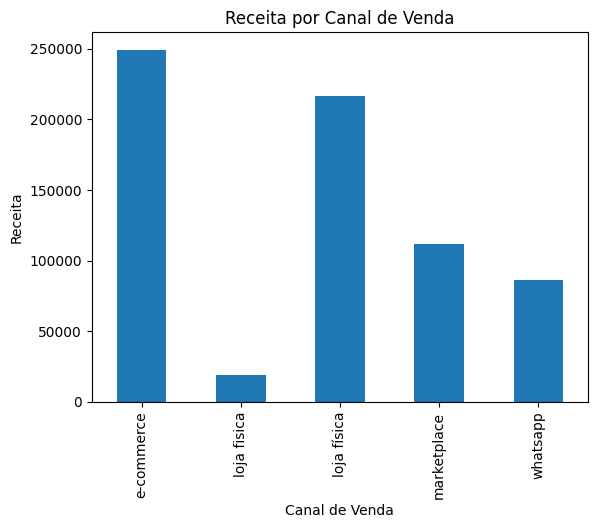

In [ ]:
# a) Gráfico de linha (line plot)

# Justificativa:
# Esse tipo de gráfico é ideal para visualizar tendências ao longo do tempo, permitindo identificar crescimento, queda ou sazonalidade na receita.

# b) Gráfico de barras (bar chart)

#Justificativa:
#Facilita a comparação entre categorias (canais), mostrando claramente qual gera mais receita.

# c) Histograma

#Justificativa:
#Permite analisar a distribuição dos preços, identificando concentração, dispersão e possíveis outliers.

#Grafico:

import matplotlib.pyplot as plt

receita_canal = df.groupby('Canal_Venda')['Receita'].sum()


plt.figure()
receita_canal.plot(kind='bar')


plt.title('Receita por Canal de Venda')
plt.xlabel('Canal de Venda')
plt.ylabel('Receita')

plt.show()

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [ ]:
df_limpo = df.copy()

df_limpo = df_limpo.dropna()

In [ ]:
df_limpo['Canal_Venda'] = (
    df_limpo['Canal_Venda']
    .str.lower()
    .str.strip()
)

In [ ]:
df_limpo['Data_Venda'] = pd.to_datetime(df_limpo['Data_Venda'])

In [ ]:
df.shape
df['Canal_Venda'].value_counts()

,count
Canal_Venda,
e-commerce,107
loja física,99
marketplace,42
whatsapp,37
loja fisica,8


In [ ]:
df_limpo.shape
df_limpo['Canal_Venda'].value_counts()

,count
Canal_Venda,
e-commerce,106
loja física,96
marketplace,39
whatsapp,33
loja fisica,8


## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**

  Uma análise de dados não deve se limitar a gráficos bonitos, pois o principal objetivo é gerar insights relevantes para a tomada de decisão. Visualizações sem contexto ou sem tratamento adequado dos dados podem levar a interpretações incorretas. É fundamental garantir a qualidade dos dados, entender o problema de negócio e interpretar os resultados de forma crítica. Além disso, a análise deve responder perguntas estratégicas e apoiar ações concretas. Dessa forma, o valor está na interpretação e na confiabilidade dos dados, e não apenas na estética das visualizações.